# Hybrid Quantum–Classical ML for Li-ion Battery Discovery

This notebook builds a judge-friendly implementation pipeline for ranking lithium-ion battery materials by predicted stability.

**Business interpretation**
- Lower `E Above Hull (eV)` indicates a stronger and more commercially reliable material candidate.
- The notebook preserves the **Chemical Formula** for final ranking and reporting.
- PCA outputs are renamed as **Compressed Material Features** for readability.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

## 2. Data Loading

The notebook loads the Kaggle lithium-ion battery dataset and keeps the **Chemical Formula** for final ranking.

In [2]:
dataset_candidates = [
    Path("lithium-ion batteries.csv"),
    Path("..") / "data" / "lithium-ion batteries.csv",
    Path("data") / "lithium-ion batteries.csv",
    Path("SRM") / "lithium-ion batteries.csv",
]

dataset_path = next((path for path in dataset_candidates if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        "Could not find 'lithium-ion batteries.csv' in the notebook folder, data folder, or SRM folder."
    )

df = pd.read_csv(dataset_path)
df.head()


,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,True,monoclinic
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,True,monoclinic
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,True,monoclinic
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,True,monoclinic
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,True,monoclinic


## 3. Convert the Dataset into Numeric Form

The model trains only on **numeric material descriptors**.  
The **Chemical Formula** is preserved separately so predictions can be mapped back to the final material.

### Key Steps

- **Target Variable**
  - `E Above Hull (eV)` is used as the prediction target
  - Lower values indicate **higher material stability**

- **Remove Non-Predictive Columns**
  - `Materials Id` is removed because it is only an identifier

- **Convert Boolean Features**
  - `Has Bandstructure` is converted to numeric format

- **Encode Categorical Features**
  - `Spacegroup`
  - `Crystal System`
  - Converted using **one-hot encoding**

- **Add Lightweight Feature Engineering**
  - `Volume per Site`
  - `Density x Volume`
  - `Band Gap x Density`
  - `Formation per Site`

- **Preserve Chemical Formula**
  - `Formula` is stored separately
  - Used later to **rank and identify candidate materials**

- **Split Dataset**
  - **80%** training data
  - **20%** testing data

- **Feature Scaling**
  - `MinMaxScaler` normalizes features before the quantum compression stage


In [3]:
target_col = "E Above Hull (eV)"

df_model = df.copy()
df_model = df_model.drop(columns=["Materials Id"]).copy()
df_model["Has Bandstructure"] = df_model["Has Bandstructure"].astype(int)

df_model["Volume per Site"] = df_model["Volume"] / df_model["Nsites"]
df_model["Density x Volume"] = df_model["Density (gm/cc)"] * df_model["Volume"]
df_model["Band Gap x Density"] = df_model["Band Gap (eV)"] * df_model["Density (gm/cc)"]
df_model["Formation per Site"] = df_model["Formation Energy (eV)"] / df_model["Nsites"]

df_model = pd.get_dummies(df_model, columns=["Spacegroup", "Crystal System"], drop_first=True)

formula = df_model["Formula"].copy()
X = df_model.drop(columns=[target_col, "Formula"])
y = df_model[target_col]

X_train, X_test, y_train, y_test, formula_train, formula_test = train_test_split(
    X, y, formula, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled[:5], columns=X.columns).head()

,Formation Energy (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Volume per Site,Density x Volume,Band Gap x Density,Formation per Site,...,Spacegroup_Pmc21,Spacegroup_Pmn21,Spacegroup_Pmnb,Spacegroup_Pn21a,Spacegroup_Pna21,Spacegroup_Pnc2,Spacegroup_Pnca,Spacegroup_Pnma,Crystal System_orthorhombic,Crystal System_triclinic
0,0.596717,0.453344,0.346535,0.099450,0.264846,1.0,0.230999,0.196462,0.366637,0.840699,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.647128,0.143008,0.188119,0.445777,0.169608,1.0,0.396881,0.179839,0.149066,0.698435,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.362251,0.894528,0.207921,0.363318,0.183574,0.0,0.378075,0.178981,0.882663,0.685265,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.801876,0.062120,0.267327,0.318841,0.233762,1.0,0.370775,0.220964,0.059432,0.805612,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.655334,0.000000,0.277228,0.276362,0.321848,0.0,0.718799,0.297473,0.000000,0.796993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 4. Classical Analysis Baseline

This step builds a stronger **classical baseline** before introducing quantum processing.

### Key Steps

- A tuned `XGBRegressor` is trained on the full engineered material descriptor set
- The model predicts the **stability score** for the held-out test dataset
- RMSE and R² are reported so the classical model can be compared fairly with the hybrid model


In [4]:
classical_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

classical_model.fit(X_train, y_train)
y_pred_classical = classical_model.predict(X_test)

classical_rmse = np.sqrt(mean_squared_error(y_test, y_pred_classical))
classical_r2 = r2_score(y_test, y_pred_classical)

pd.DataFrame({
    "Model": ["Tuned Classical Baseline"],
    "RMSE": [classical_rmse],
    "R2": [classical_r2]
})


,Model,RMSE,R2
0,Tuned Classical Baseline,0.023174,0.453942


## 5. Compress Material Features for Quantum Processing

The lithium-ion materials dataset contains multiple physical descriptors such as formation energy, band gap, density, atomic count, and crystal structure.  
However, quantum circuits can only process a limited number of input variables because each feature typically requires its own qubit.

To make the hybrid quantum model feasible on current simulators, the original material descriptors are compressed into four **Compressed Material Features** using dimensionality reduction.

Each compressed feature represents a combination of several physical properties while preserving the most important information from the dataset.

**Interpretation of the compressed features**

- **Compressed Material Feature 1** – captures dominant structural patterns across the material descriptors  
- **Compressed Material Feature 2** – summarizes electronic property relationships such as band behaviour  
- **Compressed Material Feature 3** – reflects atomic composition and density-related characteristics  
- **Compressed Material Feature 4** – represents additional interactions between structural and electronic features

This compression allows the quantum model to analyze the key material patterns efficiently while keeping the quantum circuit small enough to run on current quantum simulators.

**Feature Compression Using PCA**

The original dataset contains multiple material descriptors such as formation energy, band gap, density, atomic count, and structural properties.

Quantum circuits cannot efficiently process a large number of input variables because each feature typically requires its own qubit. To make the quantum stage computationally feasible, the feature space is compressed using **Principal Component Analysis (PCA)**.

PCA analyzes correlations between the original descriptors and creates new variables called **principal components**. Each compressed feature is a weighted combination of several physical properties and captures the most important patterns in the dataset.

In this implementation:

- PCA reduces the feature space to **four compressed material features**
- These components preserve most of the variance present in the original dataset
- The compressed features are then scaled to a **0–1 range** to enable stable quantum encoding

This step allows the hybrid quantum-classical model to process the key structural and electronic characteristics of lithium battery materials while keeping the quantum circuit small enough to run on simulators.

In [5]:
pca = PCA(n_components=4)
X_train_comp = pca.fit_transform(X_train_scaled)
X_test_comp = pca.transform(X_test_scaled)

comp_scaler = MinMaxScaler()
X_train_comp = comp_scaler.fit_transform(X_train_comp)
X_test_comp = comp_scaler.transform(X_test_comp)

compressed_feature_names = [
    "Compressed Material Feature 1",
    "Compressed Material Feature 2",
    "Compressed Material Feature 3",
    "Compressed Material Feature 4"
]

train_comp_df = pd.DataFrame(X_train_comp, columns=compressed_feature_names)
test_comp_df = pd.DataFrame(X_test_comp, columns=compressed_feature_names)

train_comp_df.head()

,Compressed Material Feature 1,Compressed Material Feature 2,Compressed Material Feature 3,Compressed Material Feature 4
0,0.568714,0.752171,0.451318,0.463902
1,0.496277,0.876768,0.439759,0.212116
2,0.634686,0.464705,0.063220,0.710099
3,0.495143,0.844049,0.441035,0.145187
4,0.058209,0.258669,0.748561,0.268732


## Quantum Feature Encoding

This section converts compressed material features into **quantum-derived features** that can be used by classical machine learning models.

Each material sample is encoded into a **quantum circuit**, simulated, and then transformed into numerical features representing the behavior of the quantum system.

---

### 1. Creating the Quantum Circuit

The function `encode_sample_to_quantum_features()` takes a compressed feature vector and builds a quantum circuit.

- The number of **qubits** is equal to the number of compressed features.
- Each feature controls a **rotation gate** applied to its corresponding qubit.

Rotation angle:

θ = π × feature_value

Since the input features are normalized between **0 and 1**, the rotation angles lie between **0 and π radians**.

---

### 2. Feature Encoding Using Rotation Gates

Each feature is encoded into the circuit using parameterized quantum gates.

Supported encoding modes include:

| Encoding Mode | Gates Applied |
|---------------|--------------|
| `rx` | Rotation around X-axis |
| `ry` | Rotation around Y-axis |
| `ry_rz` | Rotation around Y and Z axes |
| `rx_ry` | Rotation around X and Y axes |

In this experiment, the **`ry_rz` encoding strategy** is used.

Applying multiple rotations allows the circuit to represent richer quantum states.

---

### 3. Entanglement Between Qubits

After encoding the features, **CNOT gates** are applied between neighboring qubits.

This creates **quantum entanglement**, allowing qubits to interact with each other.

The entanglement structure forms a **ring topology**:

Q0 → Q1  
Q1 → Q2  
Q2 → Q3  
Q3 → Q0  

Entanglement enables the circuit to capture **relationships between material features** rather than treating each feature independently.

---

### 4. Circuit Repetition (Depth)

The encoding and entanglement layers are repeated using the parameter:

This increases the **expressive power of the circuit**, allowing more complex transformations of the input features.

---

### 5. Quantum State Simulation

The circuit is simulated using a **statevector simulator**.

This produces a probability distribution over all possible quantum states.

For a system with **N qubits**, the number of possible states is:

2^N

For example:

4 qubits → 16 possible basis states.

These probabilities form the first set of quantum features.

---

### 6. Single-Qubit Z Expectation Values

For each qubit, the expectation value of the **Pauli-Z operator** is computed.

This is calculated as:

⟨Z⟩ = P(0) − P(1)

where:

- **P(0)** = probability that the qubit is in state |0⟩  
- **P(1)** = probability that the qubit is in state |1⟩

The expectation value ranges from **-1 to +1** and represents the average measurement outcome of that qubit.

These values provide **single-qubit statistics** about the quantum state.

---

### 7. Two-Qubit Correlations (ZZ Expectations)

Next, correlations between **neighboring qubits** are calculated.

The expectation value:

⟨Zi Zj⟩

measures whether two qubits tend to be in the **same or opposite states**.

Interpretation:

| Value | Meaning |
|------|--------|
| +1 | qubits aligned |
| 0 | weak correlation |
| -1 | qubits opposite |

These correlations capture **interactions between encoded material features**.

---

### 8. Constructing the Quantum Feature Vector

The final quantum feature vector combines three components:

1. **Basis state probabilities**  
2. **Single-qubit Z expectations**  
3. **Two-qubit ZZ correlations**


For a 4-qubit circuit this results in:

- 16 probability features  
- 4 Z expectation features  
- 4 ZZ correlation features  

Total:

**24 quantum features**

---

### 9. Output of the Function

The function returns:

- `quantum_features` → numerical vector used for machine learning
- `qc` → the quantum circuit used for encoding

The circuit can be visualized using:

```python
sample_circuit.draw("mpl")


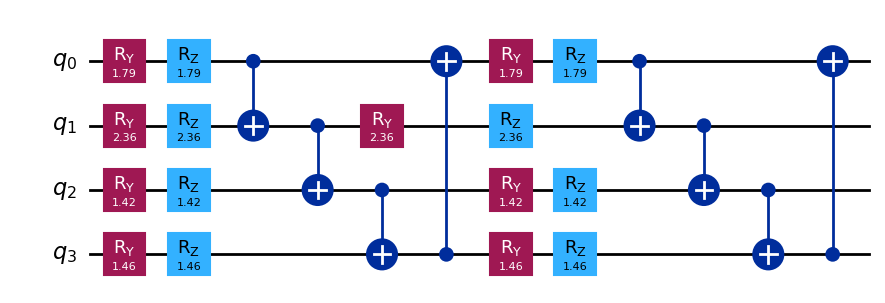

In [6]:
def encode_sample_to_quantum_features(x, mode="ry_rz", reps=2):
    n_qubits = len(x)
    qc = QuantumCircuit(n_qubits)

    for _ in range(reps):
        for i, value in enumerate(x):
            angle = np.pi * float(value)

            if mode == "rx":
                qc.rx(angle, i)
            elif mode == "ry":
                qc.ry(angle, i)
            elif mode == "ry_rz":
                qc.ry(angle, i)
                qc.rz(angle, i)
            elif mode == "rx_ry":
                qc.rx(angle, i)
                qc.ry(angle, i)
            else:
                raise ValueError(f"Unsupported encoding mode: {mode}")

        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        qc.cx(n_qubits - 1, 0)

    probabilities = Statevector.from_instruction(qc).probabilities()

    z_expectations = []
    zz_expectations = []

    for qubit in range(n_qubits):
        p0 = probabilities[[idx for idx in range(len(probabilities)) if ((idx >> qubit) & 1) == 0]].sum()
        z_expectations.append(p0 - (1 - p0))

    for qubit in range(n_qubits):
        neighbour = (qubit + 1) % n_qubits
        expectation = 0.0
        for idx, prob in enumerate(probabilities):
            zi = 1 if ((idx >> qubit) & 1) == 0 else -1
            zj = 1 if ((idx >> neighbour) & 1) == 0 else -1
            expectation += zi * zj * prob
        zz_expectations.append(expectation)

    quantum_features = np.concatenate(
        [probabilities, np.array(z_expectations), np.array(zz_expectations)]
    )
    return quantum_features, qc


sample_quantum_features, sample_circuit = encode_sample_to_quantum_features(
    X_train_comp[0],
    mode="ry_rz",
    reps=2
)

sample_quantum_features[:8]

sample_circuit.draw("mpl")


## 7. Build the Final Quantum Feature Matrix

This step converts the compressed material features into the **final quantum feature representation** used for the hybrid model.

### What the function does

The function `build_quantum_feature_matrix()` processes the dataset **row by row**.

For each material sample:

- the compressed material features are passed into `encode_sample_to_quantum_features()`
- a quantum circuit is created
- the circuit is simulated
- quantum-derived features are extracted
- the resulting feature vector is stored

At the end, all quantum feature vectors are combined into a single matrix.

---

### Selected quantum encoding strategy

The notebook manually selects:

- **Encoding mode:** `ry_rz`
- **Repetitions:** `2`

This means each material is encoded using:

- **RY rotation**
- **RZ rotation**
- **2 repeated encoding + entanglement layers**

This configuration is used as the final quantum transformation stage.

---

### What the output contains

Each material sample is transformed into a quantum feature vector containing three groups of features:

1. **Quantum Probabilities**  
   These represent the probability of measuring each possible basis state of the quantum circuit.

2. **Z Expectations**  
   These measure the average state of each individual qubit.

3. **ZZ Correlations**  
   These measure how neighboring qubits behave together.

---

### Number of quantum features

Since the circuit uses **4 qubits**:

- Number of basis states = **2⁴ = 16**
- Number of Z expectation values = **4**
- Number of ZZ correlation values = **4**

Total quantum features per material:

**16 + 4 + 4 = 24 features**

---

### Feature naming

To make the outputs readable, the notebook assigns clear labels:

- `Quantum Probability 1` to `Quantum Probability 16`
- `Z Expectation 1` to `Z Expectation 4`
- `ZZ Correlation 1` to `ZZ Correlation 4`

This makes the hybrid feature matrix easier to inspect and explain.

---

### Preview step

The final line displays the first 5 rows and the first 8 quantum probability columns to verify that the quantum feature generation process worked correctly.

In [7]:
def build_quantum_feature_matrix(X_array, mode="ry_rz", reps=2):
    features = []
    for row in X_array:
        quantum_features, _ = encode_sample_to_quantum_features(row, mode=mode, reps=reps)
        features.append(quantum_features)
    return np.array(features)


best_mode = "ry_rz"

X_train_q_best = build_quantum_feature_matrix(X_train_comp, mode=best_mode, reps=2)
X_test_q_best = build_quantum_feature_matrix(X_test_comp, mode=best_mode, reps=2)

quantum_feature_names = (
    [f"Quantum Probability {i+1}" for i in range(2 ** X_train_comp.shape[1])]
    + [f"Z Expectation {i+1}" for i in range(X_train_comp.shape[1])]
    + [f"ZZ Correlation {i+1}" for i in range(X_train_comp.shape[1])]
)

pd.DataFrame(X_train_q_best[:5], columns=quantum_feature_names).iloc[:, :8]


,Quantum Probability 1,Quantum Probability 2,Quantum Probability 3,Quantum Probability 4,Quantum Probability 5,Quantum Probability 6,Quantum Probability 7,Quantum Probability 8
0,0.029035,0.021584,0.073799,0.061125,0.002229,0.037287,0.072386,0.044078
1,0.054852,0.078432,0.062596,0.040373,0.019036,0.061268,0.024745,0.094111
2,0.110570,0.025019,0.023668,0.094846,0.035262,0.105697,0.106764,0.010717
3,0.063265,0.083532,0.054291,0.036280,0.026014,0.031750,0.044944,0.091864
4,0.172935,0.020269,0.036028,0.025754,0.013492,0.018563,0.000023,0.381221


## 8. Convert Quantum Outputs Back into Classical Form

The quantum circuit outputs are converted back into classical information using three signal families:

- Basis-state probabilities
- Single-qubit `Z` expectations
- Nearest-neighbour `ZZ` correlations

These features become the classical input for the final hybrid regression stage.


In [8]:
pd.DataFrame({
    "Hybrid Setting": [
        "Quantum Encoding",
        "Entangling Repetitions",
        "Quantum Feature Count"
    ],
    "Value": [
        best_mode,
        2,
        X_train_q_best.shape[1]
    ]
})


,Hybrid Setting,Value
0,Quantum Encoding,ry_rz
1,Entangling Repetitions,2
2,Quantum Feature Count,24


## 9. Final Classical Analysis on Quantum-Derived Features

The final hybrid regression model is trained on **quantum-derived signals** and evaluated using RMSE and R².


In [9]:
final_quantum_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

final_quantum_model.fit(X_train_q_best, y_train)
y_pred_quantum = final_quantum_model.predict(X_test_q_best)

final_quantum_rmse = np.sqrt(mean_squared_error(y_test, y_pred_quantum))
final_quantum_r2 = r2_score(y_test, y_pred_quantum)

comparison_df = pd.DataFrame({
    "Model": ["Tuned Classical Baseline", "Tuned Hybrid Quantum-Classical Model"],
    "RMSE": [classical_rmse, final_quantum_rmse],
    "R2": [classical_r2, final_quantum_r2]
})

comparison_df


,Model,RMSE,R2
0,Tuned Classical Baseline,0.023174,0.453942
1,Tuned Hybrid Quantum-Classical Model,0.024215,0.403739


## 10. Rank Chemical Formulas by Predicted Stability

The final output returns the **Chemical Formula** of the most promising materials.

**Commercial interpretation**
- Lower predicted stability score means the material is more commercially reliable and promising for battery development
- The ranking uses the **best-scoring model** from the classical-versus-hybrid comparison


In [10]:
if classical_rmse <= final_quantum_rmse:
    scoring_model_name = "Tuned Classical Baseline"
    scoring_predictions = y_pred_classical
else:
    scoring_model_name = "Tuned Hybrid Quantum-Classical Model"
    scoring_predictions = y_pred_quantum

results_df = pd.DataFrame({
    "Chemical Formula": formula_test.values,
    "Actual Stability Score": y_test.values,
    "Predicted Stability Score": scoring_predictions,
    "Scoring Model": scoring_model_name
})

ranked_candidates_df = results_df.sort_values("Predicted Stability Score", ascending=True).reset_index(drop=True)
ranked_candidates_df.head(10)


,Chemical Formula,Actual Stability Score,Predicted Stability Score,Scoring Model
0,Li2FeSiO4,0.005,0.003101,Tuned Classical Baseline
1,Li2MnSiO4,0.000,0.006814,Tuned Classical Baseline
2,Li4FeSi2O7,0.011,0.008885,Tuned Classical Baseline
3,Li6Fe(SiO4)2,0.063,0.020046,Tuned Classical Baseline
4,Li4MnSi2O7,0.024,0.023054,Tuned Classical Baseline
5,LiFeSiO4,0.014,0.023622,Tuned Classical Baseline
6,Li2MnSiO4,0.014,0.027561,Tuned Classical Baseline
7,LiFeSiO4,0.010,0.031323,Tuned Classical Baseline
8,Li2CoSiO4,0.042,0.031567,Tuned Classical Baseline
9,Li2Mn(SiO3)2,0.040,0.033455,Tuned Classical Baseline


## 11. Top Commercially Promising Material Candidate

This identifies the top-ranked chemical formula from the prediction set.

In [11]:
top_candidate = ranked_candidates_df.iloc[0]
top_candidate.to_frame(name="Top Candidate")

,Top Candidate
Chemical Formula,Li2FeSiO4
Actual Stability Score,0.005
Predicted Stability Score,0.003101
Scoring Model,Tuned Classical Baseline
